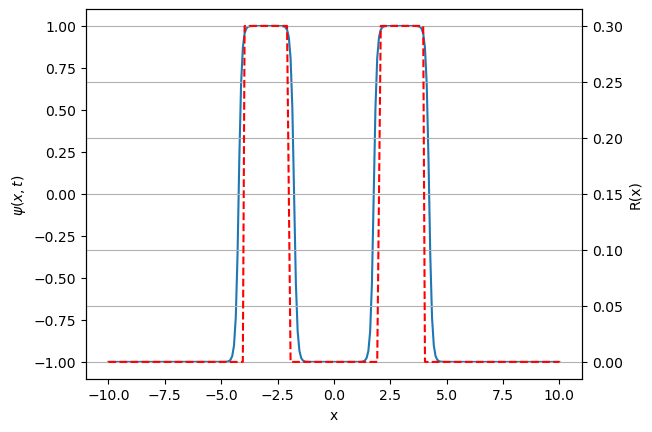

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

D = 0.01
l = 5.0
rm = 0.3
w=2

Nx = 256
x = np.linspace(-10, 10, Nx)
dx = x[1] - x[0]

def H(x):
    return 0.5 * (np.tanh(x / 0.01) + 1)

def well(x, x0, width):
    return H(x - (x0 - width/2)) - H(x - (x0 + width/2))

def R(x, sep=l, width=w):
    return well(x, -sep/2, width) + well(x, sep/2, width)

def laplacian_neumann(y):
    lap = np.zeros_like(y)

    lap[1:-1] = (y[2:] - 2*y[1:-1] + y[:-2]) / dx**2

    # Neumann: dy/dx = 0 at boundaries
    lap[0]  = 2 * (y[1] - y[0]) / dx**2
    lap[-1] = 2 * (y[-2] - y[-1]) / dx**2

    return lap


R_profile = R(x, sep=l+1.0, width=w)

def rhs(t, y):
    reaction = -(y * (y + 1) + rm * R_profile) * (y - 1)
    diffusion = D * laplacian_neumann(y)
    return reaction + diffusion

t0, tf = 0, 500

y0 = -np.ones_like(x)

sol = solve_ivp(
    rhs,
    t_span=(t0, tf),
    y0=y0,
    t_eval=np.linspace(t0, tf, 256),
    method="RK45"
)

fig, ax1 = plt.subplots()

# eje izquierdo
ax1.plot(x, sol.y[:, -1], label=f"t={tf}")
ax1.set_xlabel("x")
ax1.set_ylabel(r"$\psi(x,t)$")

# eje derecho
ax2 = ax1.twinx()
ax2.plot(x, rm * R_profile, linestyle="--", color="red", label="bead profile")
ax2.set_ylabel("R(x)")
plt.grid()
plt.show()